Author: Jayesh Bane

Email: jb4757@drexel.edu

In [1]:
# Importing necessary libraries

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

import networkx.algorithms.community as nx_comm

from matplotlib.patches import Patch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importing Chapter Code mappings

import sys
import os

sys.path.append(os.path.abspath("../data"))

from hs_chapters import hs_chapters

In [3]:
df = pd.read_excel("../data/tariff_database_2025.xlsx")
dfq1 = df.copy()

In [4]:
df.head(10)

,hts8,brief_description,quantity_1_code,quantity_2_code,wto_binding_code,mfn_text_rate,mfn_rate_type_code,mfn_ave,mfn_ad_val_rate,mfn_specific_rate,...,japan_indicator,japan_rate_type_code,japan_ad_val_rate,japan_specific_rate,japan_other_rate,usmca_indicator,usmca_rate_type_code,usmca_ad_val_rate,usmca_specific_rate,usmca_other_rate
0,1012100,Live purebred breeding horses,NO,NaN,B,Free,0,NaN,0.000,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1012900,Live horses other than purebred breeding horses,NO,NaN,B,Free,0,NaN,0.000,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1013000,Live asses,NO,NaN,B,6.8%,7,NaN,0.068,0.00,...,NaN,NaN,NaN,NaN,NaN,S,0.0,0.0,0.0,0.0
3,1019030,Mules and hinnies imported for immediate slaug...,NO,NaN,B,Free,0,NaN,0.000,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1019040,Mules and hinnies not imported for immediate s...,NO,NaN,B,4.5%,7,NaN,0.045,0.00,...,NaN,NaN,NaN,NaN,NaN,S,0.0,0.0,0.0,0.0
5,1022100,Live purebred breeding cattle,NO,NaN,B,Free,0,NaN,0.000,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1022920,Cows imported specially for dairy purposes,NO,KG,B,Free,0,NaN,0.000,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1022940,Live cattle other than purebred or those impor...,NO,KG,B,1 cents/kg,2,NaN,0.000,0.01,...,NaN,NaN,NaN,NaN,NaN,S,0.0,0.0,0.0,0.0
8,1023100,Live purebred breeding buffalo,NO,NaN,B,Free,0,NaN,0.000,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1023900,"Live buffalo, other than purebred breeding ani...",NO,KG,B,1 cents/kg,2,NaN,0.000,0.01,...,NaN,NaN,NaN,NaN,NaN,S,0.0,0.0,0.0,0.0


## Tariff Wall Similarity

In [5]:
print(f"MFN Rate Average:{df['mfn_ad_val_rate'].mean()}")
print(f"MFN Rate Minimum:{df['mfn_ad_val_rate'].min()}")
print(f"MFN Rate Maximum:{df['mfn_ad_val_rate'].max()}")

print("="*50)

print(f"Col 2 Rate Average:{df['col2_ad_val_rate'].mean()}")
print(f"Col 2 Rate Minimum:{df['col2_ad_val_rate'].min()}")
print(f"Col 2 Rate Maximum:{df['col2_ad_val_rate'].max()}")

MFN Rate Average:515.5818955350649
MFN Rate Minimum:0.0
MFN Rate Maximum:9999.999999
Col 2 Rate Average:498.66373043025385
Col 2 Rate Minimum:0.0
Col 2 Rate Maximum:10000.0


In [6]:
df['chapter'] = df['hts8'].astype(str).str.zfill(8).str[:2]

# Cleaning tariff rates as there are a lot of values like 9999.99 for high tariff items, capping these to 0.3 for normal ad val rates
df['clean_mfn'] = df['mfn_ad_val_rate']
df.loc[df['clean_mfn'] > 1.0, 'clean_mfn'] = 0.30 

# Applying the same capping logic to the col 2 rates but capping them at 0.6 as these are penalizing rates
df['clean_col2'] = df['col2_ad_val_rate']
df.loc[df['clean_col2'] > 1.0, 'clean_col2'] = 0.60

# Removing chapters '98' and '99' as they are special provisions and not industrial sectors
df = df[~df['chapter'].isin(['98', '99'])].copy()

In [7]:
# Creating "Is Duty Free" flag
df['is_free'] = (df['mfn_rate_type_code'] == '0').astype(int)

In [8]:
print(f"MFN Rate Average:{df['clean_mfn'].mean()}")
print(f"MFN Rate Minimum:{df['clean_mfn'].min()}")
print(f"MFN Rate Maximum:{df['clean_mfn'].max()}")

print("="*50)

print(f"Col 2 Rate Average:{df['clean_col2'].mean()}")
print(f"Col 2 Rate Minimum:{df['clean_col2'].min()}")
print(f"Col 2 Rate Maximum:{df['clean_col2'].max()}")

MFN Rate Average:0.04185408270544945
MFN Rate Minimum:0.0
MFN Rate Maximum:0.48
Col 2 Rate Average:0.33604456226448165
Col 2 Rate Minimum:0.0
Col 2 Rate Maximum:1.0


In [9]:
# Grouping our data based on each chapter for further chapter-wise analysis
ch_stats = df.groupby('chapter').agg(
    total_items=('hts8', 'count'),
    avg_mfn=('clean_mfn', 'mean'),
    avg_col2=('clean_col2', 'mean'),
    pct_free=('is_free', 'mean')
)

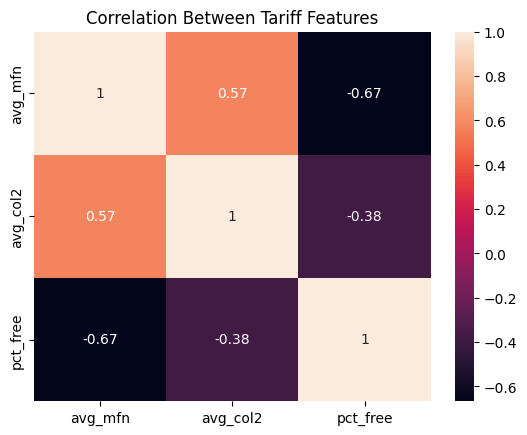

In [10]:
ax = sns.heatmap(ch_stats[['avg_mfn', 'avg_col2', 'pct_free']].corr().round(3), annot=True)
ax = ax.set_title("Correlation Between Tariff Features")

We can see that there is a moderate-strong correlation between the MFN and Col 2 Tariff rates with a score of 0.57. If an industry is highly protected from our normal trade partners, the U.S. government tends to heavily punish our restricted partners (like Cuba/North Korea) in that exact same industry.

We can consider this as a decent correlation score as this dataset is based on socio-economic data as compared to a straight forward mathematical data.

In [11]:
print("TOP 10 MOST PROTECTED CHAPTERS (Highest Avg MFN)")
top_mfn = ch_stats.sort_values(by='avg_mfn', ascending=False)[['total_items', 'avg_mfn']].head(10)
top_mfn['avg_mfn'] = (top_mfn['avg_mfn'] * 100).round(2).astype(str) + '%'
print(top_mfn)

TOP 10 MOST PROTECTED CHAPTERS (Highest Avg MFN)
         total_items avg_mfn
chapter                     
91               174  17.08%
64               147  14.94%
61               252  12.57%
78                11  11.95%
62               395  11.09%
55               133  10.73%
54               131  10.25%
60                60   10.1%
17                70   9.97%
19                80   9.38%


If we rank the 97 chapters by their average baseline tariff, we instantly see why the algorithm grouped certain chapters together:

1. Chapter 91 (Clocks & Watches): 17.08%

2. Chapter 64 (Footwear): 14.94%

3. Chapter 61 (Apparel - Knitted): 12.57%

4. Chapter 78 (Lead & Articles thereof): 11.95%

5. Chapter 62 (Apparel - Not Knitted): 11.09%

The Takeaway: Clothing, shoes, and precision mechanics (watches) form the absolute core of the U.S. "Tariff Wall." This is why the above chapters are perfectly clustered together in the network graph.

In [12]:
print("TOP 10 MOST 'FREE TRADE' CHAPTERS (Highest % Duty-Free)")
top_free = ch_stats.sort_values(by='pct_free', ascending=False)[['total_items', 'pct_free']].head(10)
top_free['pct_free'] = (top_free['pct_free'] * 100).round(2).astype(str) + '%'
print(top_free)

TOP 10 MOST 'FREE TRADE' CHAPTERS (Highest % Duty-Free)
         total_items pct_free
chapter                      
31                24   100.0%
49                29   100.0%
47                21   100.0%
48               225   100.0%
97                19   100.0%
88                28   96.43%
45                19   94.74%
72               262    91.6%
30                60    90.0%
25                79   89.87%


These are the chapters where the U.S. fundamentally operates an open border (nearly 100% of items are tax-free):

1. Chapter 49 (Printed Books/Newspapers): 100.0%

2. Chapter 31 (Fertilizers): 100.0%

3. Chapter 48 (Paper & Paperboard): 100.0%

4. Chapter 47 (Wood Pulp): 100.0%

5. Chapter 97 (Art & Antiques): 100.0%

6. Chapter 88 (Aircraft/Spacecraft): 96.4%

The Takeaway: The "Free Trade" cluster in your network is dominated by information (Books), agriculture inputs (Fertilizer), and strategic transportation (Aircraft). The U.S. government clearly decided that taxing these specific items hurts the U.S. economy more than it helps domestic producers.

In [13]:
print("TOP 10 HIGHEST PENALTY CHAPTERS (Highest Avg Col 2)")
top_col2 = ch_stats.sort_values(by='avg_col2', ascending=False)[['total_items', 'avg_col2']].head(10)
top_col2['avg_col2'] = (top_col2['avg_col2'] * 100).round(2).astype(str) + '%'
print(top_col2)

TOP 10 HIGHEST PENALTY CHAPTERS (Highest Avg Col 2)
         total_items avg_col2
chapter                      
61               252   68.26%
55               133   67.42%
54               131   66.97%
62               395   65.86%
58                72   65.39%
63                99   65.34%
56                55   63.38%
60                60    60.2%
59                59   52.67%
67                13   52.04%


Column 2 rates are the punitive tariffs applied to countries without normal trade relations. When we rank chapters by their average Column 2 rate, one massive industry completely dominates the top 10:

1. Chapter 61 (Apparel - Knitted): 68.26%

2. Chapter 55 (Man-made Staple Fibers): 67.42%

3. Chapter 54 (Man-made Filaments): 66.97%

4. Chapter 62 (Apparel - Not Knitted): 65.86%

5. Chapter 58 (Special Woven Fabrics): 65.39%

The Takeaway: Textiles and Apparel (Chapters 50 through 63) face the most hostile trade penalties in the entire U.S. code. If a restricted nation tries to sell clothing into the United States, they face an average tax wall approaching 70%.

In [14]:
# Standardizing the features for comparison
scaler = StandardScaler()
ch_scaled = scaler.fit_transform(ch_stats[['avg_mfn', 'avg_col2', 'pct_free']])

In [15]:
# Calculating similarity between tariff chapters based on their tax structure
sim_matrix = cosine_similarity(ch_scaled)
chapters = ch_stats.index.tolist()

In [16]:
G_tariff = nx.Graph()

for i in range(len(chapters)):
    G_tariff.add_node(chapters[i])
    similar_indices = np.argsort(sim_matrix[i])[::-1]
    
    added_edges = 0
    # Linking 2 most closely related nodes only to avoid hairball situations
    for j in similar_indices:
        if i != j and sim_matrix[i, j] > 0.90:
            G_tariff.add_edge(chapters[i], chapters[j], weight=sim_matrix[i, j])
            added_edges += 1
        if added_edges >= 2:
            break

In [17]:
'''
Creating clusters (aka communities) using the greedy_modularity_communities algorithm.
This function detects communities (tightly-knit groups of nodes) in a graph by iteratively merging node pairs to 
maximize modularity, which is a score measuring how dense connections are within communities compared to a random graph.

A setback of this algorithm is that due to its greedy nature, it can miss the globally optimal solution.
'''
communities = nx_comm.greedy_modularity_communities(G_tariff)

In [18]:
# Loading a colour map to colour each community from the results and creating a legend for the graph
cmap = cm.get_cmap('tab20', len(communities))
colors = [mcolors.to_hex(cmap(i)) for i in range(len(communities))]
legend_elements = []
color_map = {}
for i, comm in enumerate(communities):
    c = colors[i % len(colors)]
    
    for node in comm:
        color_map[node] = c
        
    comm_nodes = list(comm)
    
    label = f'Cluster {i+1} ({len(comm_nodes)} Chapters)'
    legend_elements.append(Patch(facecolor=c, edgecolor='black', label=label))

node_colors = [color_map.get(node, 'gray') for node in G_tariff.nodes()]

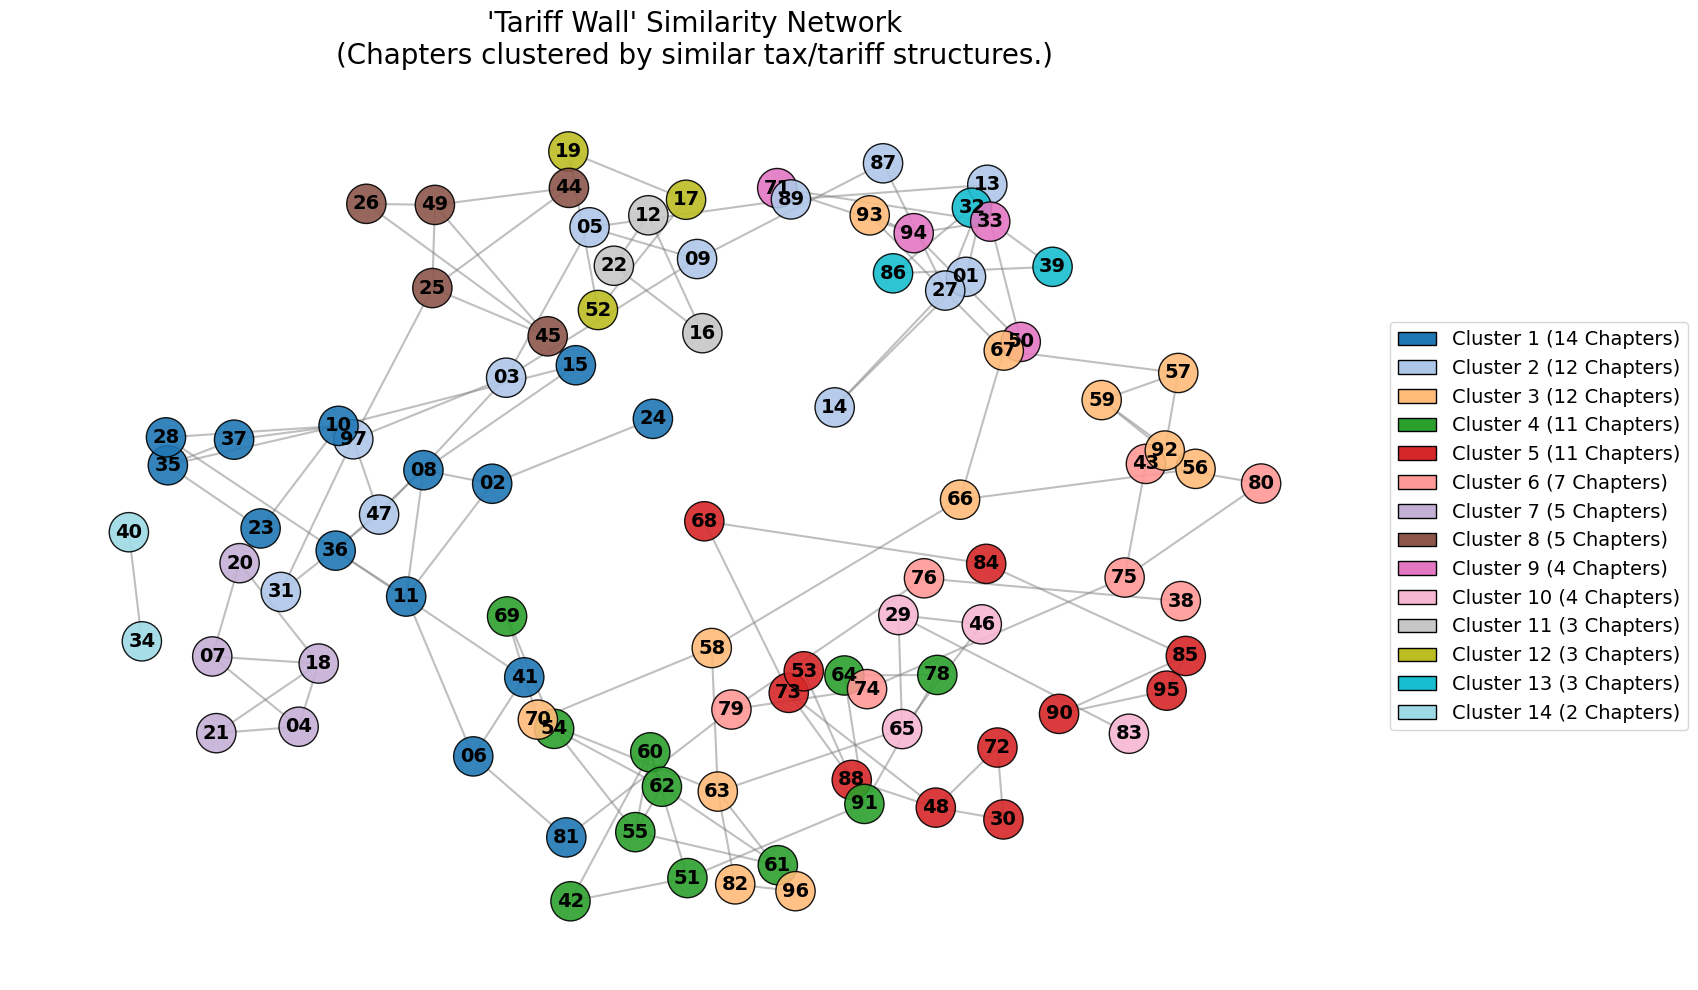

In [19]:
plt.figure(figsize=(14, 10))
pos_tariff = nx.spring_layout(G_tariff, k=0.4, iterations=50, seed=42)

nx.draw_networkx_nodes(G_tariff, pos_tariff, node_size=800, node_color=node_colors, alpha=0.9, edgecolors='black')
nx.draw_networkx_edges(G_tariff, pos_tariff, alpha=0.5, edge_color='gray', width=1.5)
nx.draw_networkx_labels(G_tariff, pos_tariff, font_size=14, font_weight='bold')

plt.title("'Tariff Wall' Similarity Network\n(Chapters clustered by similar tax/tariff structures.)", fontsize=20)
plt.axis('off')
plt.tight_layout()
plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14)
plt.show()
plt.close()

Code for creating Interactive Tariff Wall Network

In [20]:
edge_x = []
edge_y = []
for edge in G_tariff.edges():
    x0, y0 = pos_tariff[edge[0]]
    x1, y1 = pos_tariff[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=1.5, color='#888'),
    hoverinfo='none',
    mode='lines'
)

node_x = []
node_y = []
node_text = []
node_hover = []
node_color = []

for i, comm in enumerate(communities):
    c = colors[i]

    avg_mfn_cluster = ch_stats.loc[comm_nodes, 'avg_mfn'].mean() * 100
    avg_free_cluster = ch_stats.loc[comm_nodes, 'pct_free'].mean() * 100

    for node in comm:
        x, y = pos_tariff[node]
        node_x.append(x)
        node_y.append(y)
        node_text.append(node)
        
        chapter_name = hs_chapters.get(node, "Unknown Chapter")

        node_mfn = ch_stats.loc[node, 'avg_mfn'] * 100
        node_free = ch_stats.loc[node, 'pct_free'] * 100
        
        hover_info = (
            f"<b>Chapter {node}: {chapter_name}</b><br>"
            f"Cluster {i+1}<br>"
            f"<br>"
            f"<b>Chapter Stats:</b><br>"
            f"Avg MFN: {node_mfn:.2f}%<br>"
            f"Duty-Free Items: {node_free:.1f}%<br>"
            f"<br>"
            f"<b>Cluster Averages:</b><br>"
            f"Cluster MFN: {avg_mfn_cluster:.1f}%<br>"
            f"Cluster Duty-Free: {avg_free_cluster:.1f}%"
        )
                
        node_hover.append(hover_info)
        node_color.append(c)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    text=node_text,
    textposition="middle center",
    hoverinfo='text',
    hovertext=node_hover,
    textfont=dict(color='black', size=14, family='Arial Black'),
    marker=dict(
        showscale=False,
        color=node_color,
        size=28,
        line_width=1.5,
        line_color='black'
    )
)

fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title="Interactive Tariff Wall Similarity Network",
                font_size=16,
                showlegend=False,
                hovermode='closest',
                plot_bgcolor='white',
                margin=dict(b=20,l=5,r=5,t=60),
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                )

fig.write_html("../exports/interactive_tariff_network.html")

## Hypothesis: The Preference Exclusion Effect

### 1. Hypothesis Definition

The Preference Exclusion Hypothesis suggests that U.S. trade policy follows a "Conditional Generosity" model. While the U.S. offers duty-free access to developing nations through programs like the Generalized System of Preferences (GSP) and the African Growth and Opportunity Act (AGOA), this generosity is not universal.

The Theory: The U.S. is most likely to exclude products from these "Free Trade" programs if those products belong to industries that are already highly protected by a domestic "Tariff Wall."

### 2. Methodology & Intuition

To test this, we segment the standard U.S. Tariff Schedule into three tiers based on the Most Favored Nation (MFN) rate:

- The Open Gate (0%): Products that are already duty-free for everyone.

- The Low Wall (0.1% - 5%): Products with minimal baseline protection.

- The High Wall (> 5%): Products the U.S. actively protects (e.g., Textiles, Footwear).

We then calculate the percentage eligibility for each tariff category for each of the two Developing Nation Programs

In [21]:
# Cleaning the MFN rate by ignoring extremely high values as these are far and few
dfq1['clean_mfn'] = dfq1['mfn_ad_val_rate']
dfq1.loc[dfq1['clean_mfn'] > 1.0, 'clean_mfn'] = np.nan 

# Extract Chapters
dfq1['chapter'] = dfq1['hts8'].astype(str).str.zfill(8).str[:2]

# Creating flags for Developing Nation Programs (1 if eligible, 0 if not)
# GSP = Generalized System of Preferences, AGOA = African Growth and Opportunity Act
dfq1['has_gsp'] = dfq1['gsp_indicator'].notna().astype(int)
dfq1['has_agoa'] = dfq1['agoa_indicator'].notna().astype(int)

# Filtering out special administrative chapters 98 and 99
df_test = dfq1[~dfq1['chapter'].isin(['98', '99'])].copy()
df_test = df_test.dropna(subset=['clean_mfn'])

# Binning the items based on their "Tariff Wall" height
df_test['tariff_wall'] = pd.cut(
    df_test['clean_mfn'], 
    bins=[-0.01, 0.001, 0.05, 1.0], 
    labels=['Duty-Free (0%)', 'Low Tariff (0-5%)', 'High Wall (>5%)']
)

# Calculate the percentage of items in each tariff-tier that are granted duty-free access for the above mentioned developing nations program
summary = df_test.groupby('tariff_wall', observed=False).agg(
    Total_Products=('hts8', 'count'),
    Avg_MFN_Rate=('clean_mfn', 'mean'),
    Percent_Granted_GSP=('has_gsp', lambda x: x.mean() * 100),
    Percent_Granted_AGOA=('has_agoa', lambda x: x.mean() * 100)
).round(2)

print("Hypothesis Test Results:")
summary.style.set_properties(**{'font-size': '20pt'})

Hypothesis Test Results:


,Total_Products,Avg_MFN_Rate,Percent_Granted_GSP,Percent_Granted_AGOA
tariff_wall,,,,
Duty-Free (0%),5073,0.000000,12.240000,12.730000
Low Tariff (0-5%),2793,0.030000,91.050000,91.510000
High Wall (>5%),3383,0.100000,55.960000,60.720000


### 3. Key Findings

- The Duty-Free Anomaly: Only ~12% of the "Duty-Free" tier has a GSP or AGOA indicator. This is expected if an item already has a 0% tariff for the whole world, the government rarely needs to apply a special "developing nation" discount to it.

- The Safety Valve Effect: For products with low domestic protection (under 5%), the U.S. is extremely generous, waiving the tax and granting over 91% of these items duty-free status for developing nations.

- The Exclusion Barrier: Once an industry is deemed "sensitive" (an MFN rate > 5%), the exclusion rate spikes. Only ~56% of high-tariff items are granted GSP status.

### 4. Conclusion

The data supports the Preference Exclusion Hypothesis. U.S. trade preferences are highly conditional. The U.S. is happy to trade freely with developing nations, but only in categories where it isn't already trying to aggressively protect domestic manufacturers. The higher the domestic tariff wall, the less likely a developing nation is allowed to bypass it.